In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_patient_files, get_column_groups, summarize_missing

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

print("All imports successful!")

All imports successful!


In [2]:
#2— LOAD THE DATA - Load Set A only first (faster for exploration):

In [3]:
df = load_patient_files("../data/raw/setA", max_patients=5000)


Loading 5000 patient files...
  2000/5000 patients loaded...
  4000/5000 patients loaded...
Combining into single DataFrame...

=== Dataset Loaded ===
Total rows (patient-hours) : 194,835
Unique patients            : 5,000
Columns                    : 42
Sepsis cases (hours)       : 4,267
Sepsis rate                : 2.19%


In [4]:
#3 — Look at the raw data:

In [5]:
df.head(10)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001
5,110.0,91.0,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001
6,108.0,92.0,36.11,123.0,77.00,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,7,0,p000001
7,106.0,90.5,NaN,93.0,76.33,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,8,0,p000001
8,104.0,95.0,NaN,133.0,88.33,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,9,0,p000001
9,102.0,91.0,NaN,134.0,87.33,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,10,0,p000001


In [6]:
#4 — Basic shape:

In [7]:
print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.dtypes

Shape: (194835, 42)
Rows: 194,835
Columns: 42


HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelets           float64
Age                 float64
Gender              

In [8]:
#5 — Missing data report:

In [9]:
missing = summarize_missing(df)
print("Top 15 columns with most missing data:")
print(missing.head(15).to_string(index=False))

Top 15 columns with most missing data:
          column  missing_rate  missing_pct
           EtCO2      1.000000        100.0
       TroponinI      0.998773         99.9
Bilirubin_direct      0.998322         99.8
      Fibrinogen      0.992178         99.2
 Bilirubin_total      0.987949         98.8
    Alkalinephos      0.985459         98.5
             AST      0.985064         98.5
         Lactate      0.964652         96.5
             PTT      0.951775         95.2
         Calcium      0.950933         95.1
       Phosphate      0.949876         95.0
            SaO2      0.949229         94.9
       Platelets      0.934883         93.5
      Creatinine      0.934226         93.4
             WBC      0.924659         92.5


In [10]:
#6. Patient Age Distribution

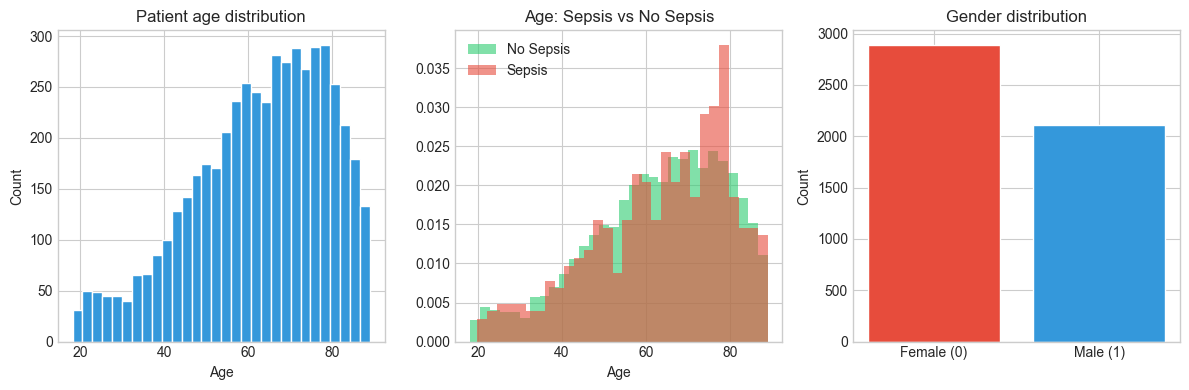

Average age: 62.7 years
Sepsis patients avg age: 63.7 years
Non-sepsis patients avg age: 62.6 years


In [11]:
# Get one row per patient (demographics don't change hour to hour)
patients = df.groupby('patient_id').first().reset_index()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
patients['Age'].hist(bins=30, color='#3498db', edgecolor='white')
plt.title('Patient age distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sepsis_patients = df[df['SepsisLabel']==1]['patient_id'].unique()
sepsis_ages = patients[patients['patient_id'].isin(sepsis_patients)]['Age']
no_sepsis_ages = patients[~patients['patient_id'].isin(sepsis_patients)]['Age']
plt.hist(no_sepsis_ages, bins=30, alpha=0.6, color='#2ecc71', 
         label='No Sepsis', density=True)
plt.hist(sepsis_ages, bins=30, alpha=0.6, color='#e74c3c', 
         label='Sepsis', density=True)
plt.title('Age: Sepsis vs No Sepsis')
plt.xlabel('Age')
plt.legend()

plt.subplot(1, 3, 3)
gender_counts = patients['Gender'].value_counts()
plt.bar(['Female (0)', 'Male (1)'], gender_counts.values, 
        color=['#e74c3c','#3498db'], edgecolor='white')
plt.title('Gender distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('age_gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average age: {patients['Age'].mean():.1f} years")
print(f"Sepsis patients avg age: {sepsis_ages.mean():.1f} years")
print(f"Non-sepsis patients avg age: {no_sepsis_ages.mean():.1f} years")

In [12]:
#7 — Vital signs: sepsis vs no sepsis:

HR       | No Sepsis avg: 85.0 | Sepsis avg: 90.5 | Difference: +5.5
O2Sat    | No Sepsis avg: 97.3 | Sepsis avg: 96.9 | Difference: -0.4
Temp     | No Sepsis avg: 37.0 | Sepsis avg: 37.3 | Difference: +0.2
SBP      | No Sepsis avg: 120.4 | Sepsis avg: 120.1 | Difference: -0.3
MAP      | No Sepsis avg: 78.4 | Sepsis avg: 77.5 | Difference: -1.0
DBP      | No Sepsis avg: 59.7 | Sepsis avg: 59.3 | Difference: -0.4
Resp     | No Sepsis avg: 18.7 | Sepsis avg: 20.6 | Difference: +1.9


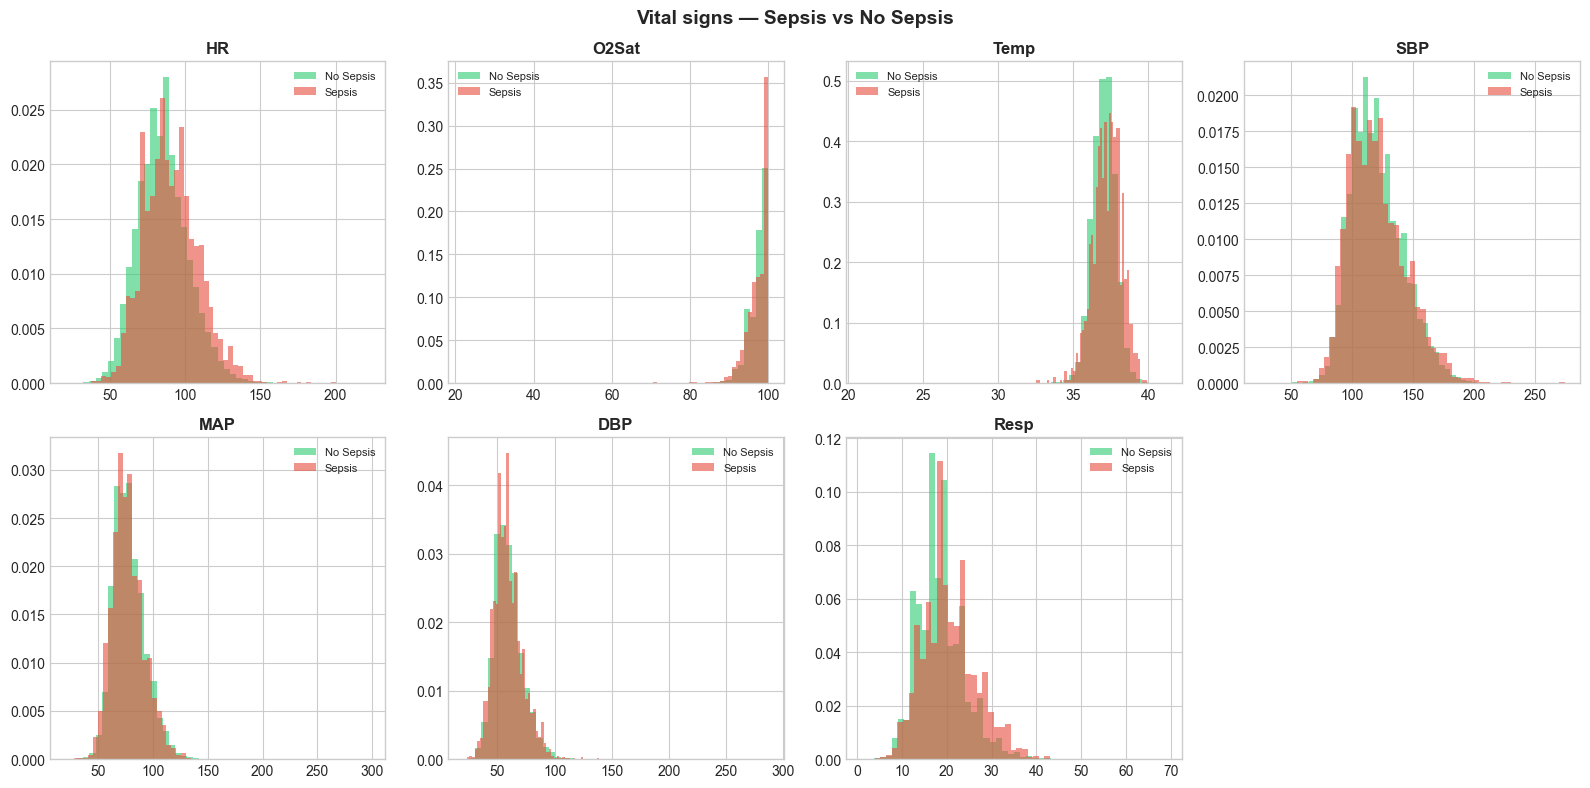

In [13]:
cols = get_column_groups()
vitals = cols['vitals']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vitals):
    sepsis_vals = df[df.SepsisLabel==1][col].dropna()
    normal_vals = df[df.SepsisLabel==0][col].dropna()
    
    axes[i].hist(normal_vals, bins=50, alpha=0.6,
                 color='#2ecc71', label='No Sepsis', density=True)
    axes[i].hist(sepsis_vals, bins=50, alpha=0.6,
                 color='#e74c3c', label='Sepsis', density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    
    # Print the difference
    diff = sepsis_vals.mean() - normal_vals.mean()
    print(f"{col:8} | No Sepsis avg: {normal_vals.mean():.1f} "
          f"| Sepsis avg: {sepsis_vals.mean():.1f} "
          f"| Difference: {diff:+.1f}")

axes[-1].set_visible(False)
plt.suptitle('Vital signs — Sepsis vs No Sepsis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vitals_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 8 — ICU stay length:

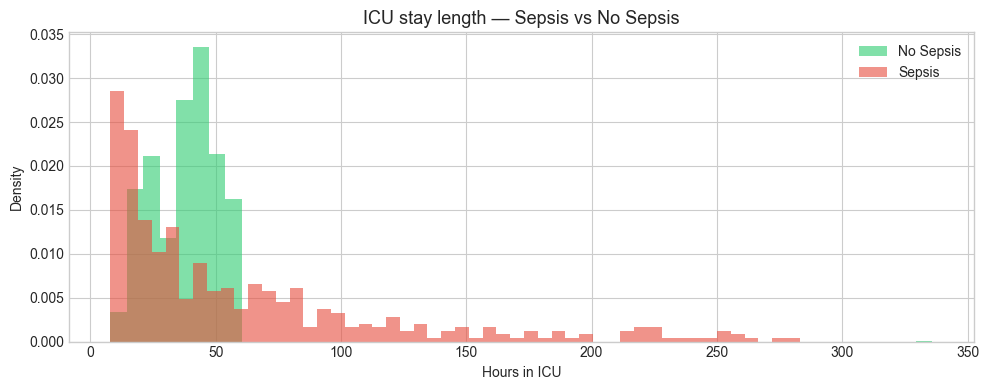

Avg ICU stay — No Sepsis : 37.8 hours
Avg ICU stay — Sepsis    : 59.9 hours
Sepsis patients stay 1.6x longer


In [15]:
stay_length = df.groupby('patient_id')['ICULOS'].max().reset_index()
stay_length.columns = ['patient_id', 'icu_hours']

sepsis_stay = stay_length[
    stay_length['patient_id'].isin(sepsis_patients)]['icu_hours']
normal_stay = stay_length[
    ~stay_length['patient_id'].isin(sepsis_patients)]['icu_hours']

plt.figure(figsize=(10, 4))
plt.hist(normal_stay, bins=50, alpha=0.6, color='#2ecc71',
         label='No Sepsis', density=True)
plt.hist(sepsis_stay, bins=50, alpha=0.6, color='#e74c3c',
         label='Sepsis', density=True)
plt.title('ICU stay length — Sepsis vs No Sepsis', fontsize=13)
plt.xlabel('Hours in ICU')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('icu_stay_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg ICU stay — No Sepsis : {normal_stay.mean():.1f} hours")
print(f"Avg ICU stay — Sepsis    : {sepsis_stay.mean():.1f} hours")
print(f"Sepsis patients stay {sepsis_stay.mean()/normal_stay.mean():.1f}x longer")

In [16]:
# Cell 9 — Your EDA Summary
print("=" * 55)
print("EDA SUMMARY — SEPSIS EARLY WARNING SYSTEM")
print("=" * 55)

print(f"""
DATASET
  Patients loaded    : 5,000 (of 40,336 total)
  Patient-hours      : {len(df):,}
  Features           : {df.shape[1]}
  Sepsis rate        : {df['SepsisLabel'].mean()*100:.2f}%

KEY FINDINGS
  1. Age is NOT a strong predictor
     Sepsis avg age   : {sepsis_ages.mean():.1f} yrs
     No-sepsis avg age: {no_sepsis_ages.mean():.1f} yrs
     Difference       : only {abs(sepsis_ages.mean()-no_sepsis_ages.mean()):.1f} years

  2. Vital sign snapshots are weak signals
     Heart rate diff  : only +5.5 bpm
     Resp rate diff   : only +1.9 bpm
     BP difference    : near zero
     → Trends matter more than snapshots

  3. Sepsis patients stay 1.6x longer in ICU
     No sepsis        : 37.8 hours avg
     Sepsis           : 59.9 hours avg
     → Earlier detection = earlier treatment = shorter stays

  4. Massive missing data in lab values
     EtCO2            : 100% missing → will DROP
     TroponinI        : 99.9% missing → keep as indicator
     Lactate          : 96.5% missing → keep as indicator
     → Presence of a lab test is itself a feature

MODELING IMPLICATIONS
  - Must use rolling window features (6hr trends)
  - Must handle class imbalance (only 2.19% sepsis hours)
  - Must use AUC-ROC not accuracy as metric
  - Must create 'was_measured' binary features for sparse labs
""")
print("=" * 55)

EDA SUMMARY — SEPSIS EARLY WARNING SYSTEM

DATASET
  Patients loaded    : 5,000 (of 40,336 total)
  Patient-hours      : 194,835
  Features           : 42
  Sepsis rate        : 2.19%

KEY FINDINGS
  1. Age is NOT a strong predictor
     Sepsis avg age   : 63.7 yrs
     No-sepsis avg age: 62.6 yrs
     Difference       : only 1.1 years

  2. Vital sign snapshots are weak signals
     Heart rate diff  : only +5.5 bpm
     Resp rate diff   : only +1.9 bpm
     BP difference    : near zero
     → Trends matter more than snapshots

  3. Sepsis patients stay 1.6x longer in ICU
     No sepsis        : 37.8 hours avg
     Sepsis           : 59.9 hours avg
     → Earlier detection = earlier treatment = shorter stays

  4. Massive missing data in lab values
     EtCO2            : 100% missing → will DROP
     TroponinI        : 99.9% missing → keep as indicator
     Lactate          : 96.5% missing → keep as indicator
     → Presence of a lab test is itself a feature

MODELING IMPLICATIONS
  -

In [17]:
# Import our new feature pipeline
from src.features import run_feature_pipeline

# Run it on our loaded data
print("Running feature pipeline on 5000 patients...")
df_features = run_feature_pipeline(df)


Running feature pipeline on 5000 patients...
Starting feature engineering pipeline...
Input shape: (194835, 42)
  Step 1: Dropping useless columns...
  Step 2: Adding was_measured flags...
  Step 3: Forward filling lab values...
  Step 4: Adding rolling features (window=6hrs)...
  Step 5: Adding SOFA proxy score...
Output shape: (194835, 89)
New features added: 47
Feature engineering complete.


In [18]:
# See all our new feature names
original_cols = df.columns.tolist()
new_cols = [c for c in df_features.columns if c not in original_cols]

print(f"Original features : {len(original_cols)}")
print(f"New features added: {len(new_cols)}")
print(f"Total features    : {df_features.shape[1]}")
print(f"\nNew features created:")
for col in new_cols:
    print(f"  {col}")

Original features : 42
New features added: 48
Total features    : 89

New features created:
  Lactate_measured
  WBC_measured
  Creatinine_measured
  Bilirubin_total_measured
  TroponinI_measured
  Fibrinogen_measured
  Platelets_measured
  pH_measured
  BaseExcess_measured
  HCO3_measured
  Glucose_measured
  Potassium_measured
  HR_mean_6hr
  HR_std_6hr
  HR_min_6hr
  HR_max_6hr
  HR_trend_6hr
  O2Sat_mean_6hr
  O2Sat_std_6hr
  O2Sat_min_6hr
  O2Sat_max_6hr
  O2Sat_trend_6hr
  Temp_mean_6hr
  Temp_std_6hr
  Temp_min_6hr
  Temp_max_6hr
  Temp_trend_6hr
  SBP_mean_6hr
  SBP_std_6hr
  SBP_min_6hr
  SBP_max_6hr
  SBP_trend_6hr
  MAP_mean_6hr
  MAP_std_6hr
  MAP_min_6hr
  MAP_max_6hr
  MAP_trend_6hr
  DBP_mean_6hr
  DBP_std_6hr
  DBP_min_6hr
  DBP_max_6hr
  DBP_trend_6hr
  Resp_mean_6hr
  Resp_std_6hr
  Resp_min_6hr
  Resp_max_6hr
  Resp_trend_6hr
  sofa_proxy


In [19]:
# Find a patient who DID get sepsis
# and look at their HR_trend_6hr in the hours leading up to it

sepsis_patients = df_features[
    df_features['SepsisLabel']==1
]['patient_id'].unique()

# Pick the first sepsis patient
patient_id = sepsis_patients[0]
print(f"Looking at patient: {patient_id}")

# Get their full timeline
patient_data = df_features[
    df_features['patient_id']==patient_id
][['ICULOS','HR','HR_mean_6hr','HR_trend_6hr',
   'Resp','Resp_trend_6hr','sofa_proxy','SepsisLabel']].reset_index(drop=True)

print(patient_data.to_string())

Looking at patient: p000009
     ICULOS     HR  HR_mean_6hr  HR_trend_6hr   Resp  Resp_trend_6hr  sofa_proxy  SepsisLabel
0         1    NaN          NaN           NaN    NaN             NaN           0            0
1         2  117.0   117.000000           NaN  20.00             NaN           0            0
2         3    NaN   117.000000           NaN    NaN             NaN           0            0
3         4    NaN   117.000000           NaN    NaN             NaN           0            0
4         5    NaN   117.000000           NaN    NaN             NaN           0            0
5         6    NaN   117.000000           NaN    NaN             NaN           0            0
6         7  120.0   118.500000           NaN  30.00             NaN           1            0
7         8  109.5   114.750000     -1.250000  27.00        1.166667           1            0
8         9  102.5   110.666667           NaN  24.50             NaN           1            0
9        10   98.0   107.500000 

In [20]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Save the engineered features
df_features.to_parquet(
    "../data/processed/features_5000.parquet",
    index=False
)
print(f"Saved to data/processed/features_5000.parquet")
print(f"Shape: {df_features.shape}")
print(f"File size: {os.path.getsize('../data/processed/features_5000.parquet')/1e6:.1f} MB")

Saved to data/processed/features_5000.parquet
Shape: (194835, 89)
File size: 14.5 MB


Sepsis diagnosed at hour: 249


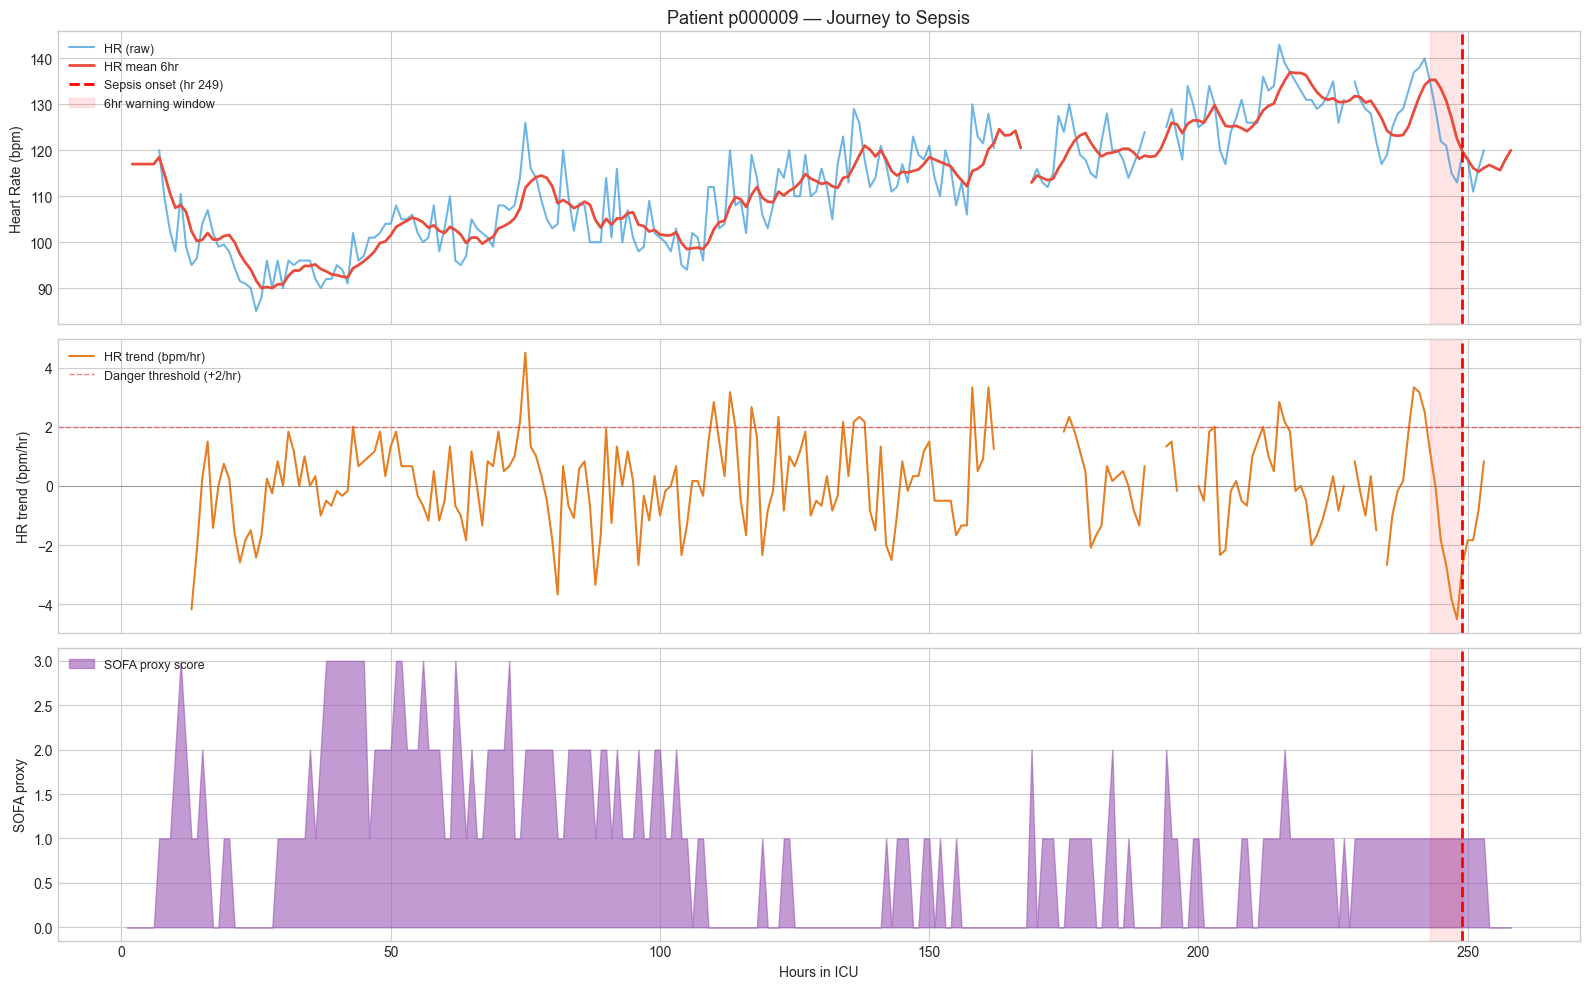

Chart saved.


In [21]:
# Visualize patient p000009's journey to sepsis
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

patient = df_features[df_features['patient_id']=='p000009'].reset_index(drop=True)

# Find sepsis onset hour
sepsis_hour = patient[patient['SepsisLabel']==1]['ICULOS'].min()
print(f"Sepsis diagnosed at hour: {sepsis_hour}")

# Plot 1 — Heart Rate + trend
ax1 = axes[0]
ax1.plot(patient['ICULOS'], patient['HR'],
         color='#3498db', linewidth=1.5, label='HR (raw)', alpha=0.7)
ax1.plot(patient['ICULOS'], patient['HR_mean_6hr'],
         color='#e74c3c', linewidth=2, label='HR mean 6hr')
ax1.axvline(x=sepsis_hour, color='red',
            linestyle='--', linewidth=2, label=f'Sepsis onset (hr {sepsis_hour})')
ax1.axvspan(sepsis_hour-6, sepsis_hour,
            alpha=0.1, color='red', label='6hr warning window')
ax1.set_ylabel('Heart Rate (bpm)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Patient p000009 — Journey to Sepsis', fontsize=13)

# Plot 2 — HR Trend
ax2 = axes[1]
ax2.plot(patient['ICULOS'], patient['HR_trend_6hr'],
         color='#e67e22', linewidth=1.5, label='HR trend (bpm/hr)')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=2, color='red', linestyle='--',
            linewidth=1, alpha=0.5, label='Danger threshold (+2/hr)')
ax2.axvline(x=sepsis_hour, color='red', linestyle='--', linewidth=2)
ax2.axvspan(sepsis_hour-6, sepsis_hour, alpha=0.1, color='red')
ax2.set_ylabel('HR trend (bpm/hr)')
ax2.legend(loc='upper left', fontsize=9)

# Plot 3 — SOFA proxy
ax3 = axes[2]
ax3.fill_between(patient['ICULOS'], patient['sofa_proxy'],
                 alpha=0.6, color='#9b59b6', label='SOFA proxy score')
ax3.axvline(x=sepsis_hour, color='red', linestyle='--', linewidth=2)
ax3.axvspan(sepsis_hour-6, sepsis_hour, alpha=0.1, color='red')
ax3.set_ylabel('SOFA proxy')
ax3.set_xlabel('Hours in ICU')
ax3.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('patient_sepsis_journey.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [22]:
#Prepare features and target

In [23]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Columns we don't feed into the model
NON_FEATURE_COLS = [
    'patient_id', 'SepsisLabel',
    'Unit1', 'Unit2', 'HospAdmTime'
]

# Everything else is a feature
feature_cols = [
    c for c in df_features.columns
    if c not in NON_FEATURE_COLS
]

print(f"Feature columns: {len(feature_cols)}")
print(f"First 10: {feature_cols[:10]}")

Feature columns: 84
First 10: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'BaseExcess', 'HCO3', 'FiO2']


In [24]:
#Fill remaining NaN values

In [25]:
# After forward fill, some NaN remain (patient's very first hours)
# Fill with median — safe, robust to outliers
df_model = df_features.copy()
df_model[feature_cols] = df_model[feature_cols].fillna(
    df_model[feature_cols].median()
)

# Verify no NaN left
remaining_nan = df_model[feature_cols].isnull().sum().sum()
print(f"Remaining NaN values: {remaining_nan}")
print("Ready for modeling." if remaining_nan == 0 else "Still has NaN!")

Remaining NaN values: 0
Ready for modeling.


In [26]:
#Split by patient not by row

In [27]:
# This is critical — we split by patient ID
# not by individual rows
# If we split by rows, hours from the same patient
# could appear in both train and test — data leakage!

X = df_model[feature_cols]
y = df_model['SepsisLabel']
groups = df_model['patient_id']

# GroupShuffleSplit keeps all hours of one patient
# in either train OR test — never both
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print(f"Training set   : {X_train.shape[0]:,} rows, "
      f"{y_train.sum():,} sepsis cases "
      f"({y_train.mean()*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]:,} rows, "
      f"{y_test.sum():,} sepsis cases "
      f"({y_test.mean()*100:.1f}%)")
print(f"\nUnique train patients: "
      f"{groups.iloc[train_idx].nunique():,}")
print(f"Unique test patients : "
      f"{groups.iloc[test_idx].nunique():,}")

Training set   : 156,272 rows, 3,573 sepsis cases (2.3%)
Test set       : 38,563 rows, 694 sepsis cases (1.8%)

Unique train patients: 4,000
Unique test patients : 1,000


In [28]:
#Handle class IMBALANCE with SMOTE

In [29]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE:")
print(f"  No sepsis : {(y_train==0).sum():,}")
print(f"  Sepsis    : {(y_train==1).sum():,}")
print(f"  Ratio     : {y_train.mean()*100:.1f}% sepsis")

# Removed n_jobs=-1 — not supported in this version
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train, y_train
)

print(f"\nAfter SMOTE:")
print(f"  No sepsis : {(y_train_balanced==0).sum():,}")
print(f"  Sepsis    : {(y_train_balanced==1).sum():,}")
print(f"  Ratio     : {y_train_balanced.mean()*100:.1f}% sepsis")

Before SMOTE:
  No sepsis : 152,699
  Sepsis    : 3,573
  Ratio     : 2.3% sepsis

After SMOTE:
  No sepsis : 152,699
  Sepsis    : 152,699
  Ratio     : 50.0% sepsis


In [30]:
#MLFlow tracking

In [31]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Set up MLflow — creates a local folder called mlruns
mlflow.set_experiment("sepsis-early-warning")
print("MLflow experiment ready.")

MLflow experiment ready.


In [32]:
#Train LOGISTIC REGRESSION

In [33]:
from sklearn.preprocessing import StandardScaler

# Scale features — Logistic Regression needs this
# XGBoost doesn't, but we do it here for consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)

print("Training Logistic Regression baseline...")

with mlflow.start_run(run_name="logistic_regression_baseline"):

    # Train the model
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    lr.fit(X_train_scaled, y_train_balanced)

    # Get predictions
    y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
    y_pred       = (y_pred_proba >= 0.5).astype(int)

    # Calculate metrics
    auc     = roc_auc_score(y_test, y_pred_proba)
    report  = classification_report(y_test, y_pred, output_dict=True)
    recall  = report['1']['recall']
    precision = report['1']['precision']

    # Log everything to MLflow
    mlflow.log_param("model",     "logistic_regression")
    mlflow.log_param("threshold", 0.5)
    mlflow.log_metric("auc_roc",  auc)
    mlflow.log_metric("recall",   recall)
    mlflow.log_metric("precision",precision)
    mlflow.sklearn.log_model(lr, "model")

    print(f"\n=== Logistic Regression Results ===")
    print(f"AUC-ROC   : {auc:.4f}")
    print(f"Recall    : {recall:.4f}  ← % of sepsis cases caught")
    print(f"Precision : {precision:.4f}  ← % of alerts that are real")
    print(f"MLflow run logged.")

Training Logistic Regression baseline...


2026/03/15 12:33:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 12:33:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Logistic Regression Results ===
AUC-ROC   : 0.6969
Recall    : 0.5807  ← % of sepsis cases caught
Precision : 0.0373  ← % of alerts that are real
MLflow run logged.


In [34]:
# Plot Confusion Matrix

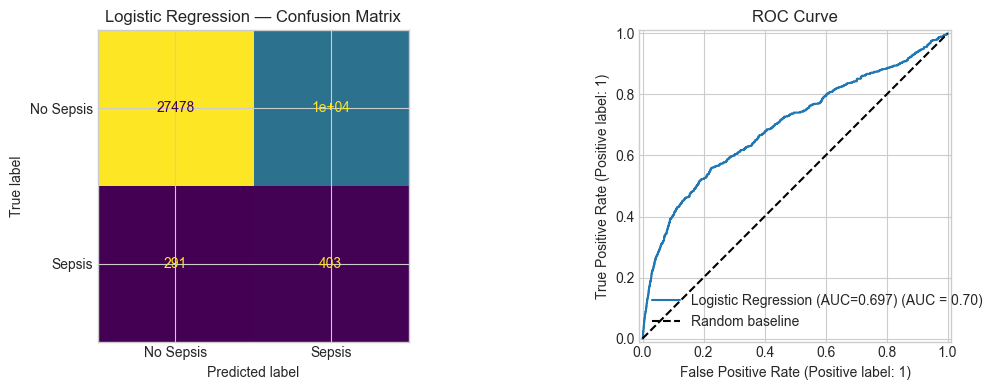

Results saved.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Sepsis', 'Sepsis']
)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')

# ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[1],
    name=f"Logistic Regression (AUC={auc:.3f})"
)
axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('lr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved.")

In [36]:
#XGBoost

In [37]:
import xgboost as xgb

print("Training XGBoost — takes 2-3 minutes...")

with mlflow.start_run(run_name="xgboost_v1"):

    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )

    xgb_model.fit(
        X_train_balanced,
        y_train_balanced,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_pred_xgb       = (y_pred_proba_xgb >= 0.5).astype(int)

    auc_xgb       = roc_auc_score(y_test, y_pred_proba_xgb)
    report_xgb    = classification_report(
                        y_test, y_pred_xgb, output_dict=True)
    recall_xgb    = report_xgb['1']['recall']
    precision_xgb = report_xgb['1']['precision']

    mlflow.log_param("model",        "xgboost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth",    6)
    mlflow.log_param("learning_rate",0.05)
    mlflow.log_metric("auc_roc",     auc_xgb)
    mlflow.log_metric("recall",      recall_xgb)
    mlflow.log_metric("precision",   precision_xgb)
    mlflow.sklearn.log_model(xgb_model, "model")

    print(f"\n=== XGBoost Results ===")
    print(f"AUC-ROC   : {auc_xgb:.4f}")
    print(f"Recall    : {recall_xgb:.4f}")
    print(f"Precision : {precision_xgb:.4f}")
    print(f"\n=== Improvement over Logistic Regression ===")
    print(f"AUC-ROC   : {auc_xgb - 0.6969:+.4f}")
    print(f"Recall    : {recall_xgb - 0.5807:+.4f}")
    print(f"Precision : {precision_xgb - 0.0373:+.4f}")

Training XGBoost — takes 2-3 minutes...


2026/03/15 12:33:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 12:33:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== XGBoost Results ===
AUC-ROC   : 0.7328
Recall    : 0.0951
Precision : 0.1075

=== Improvement over Logistic Regression ===
AUC-ROC   : +0.0359
Recall    : -0.4856
Precision : +0.0702


In [38]:
#tune the threshold

In [39]:
# Try different thresholds and see how metrics change
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Threshold':>10} {'AUC':>8} {'Recall':>8} "
      f"{'Precision':>10} {'F1':>8}")
print("-" * 50)

best_threshold = 0.5
best_recall = 0

for thresh in thresholds:
    y_pred_t = (y_pred_proba_xgb >= thresh).astype(int)
    rep = classification_report(
              y_test, y_pred_t, output_dict=True, zero_division=0)
    
    rec  = rep['1']['recall']
    prec = rep['1']['precision']
    f1   = rep['1']['f1-score']

    print(f"{thresh:>10.1f} {auc_xgb:>8.4f} "
          f"{rec:>8.4f} {prec:>10.4f} {f1:>8.4f}")

    if rec > best_recall:
        best_recall    = rec
        best_threshold = thresh

print(f"\nBest threshold for recall: {best_threshold}")

 Threshold      AUC   Recall  Precision       F1
--------------------------------------------------
       0.1   0.7328   0.6772     0.0375   0.0710
       0.2   0.7328   0.4366     0.0558   0.0989
       0.3   0.7328   0.2738     0.0777   0.1211
       0.4   0.7328   0.1671     0.0907   0.1176
       0.5   0.7328   0.0951     0.1075   0.1009

Best threshold for recall: 0.1


In [40]:
#Apply best threshold

In [41]:
# Apply best threshold
THRESHOLD = 0.3

y_pred_final = (y_pred_proba_xgb >= THRESHOLD).astype(int)
report_final = classification_report(
                   y_test, y_pred_final, output_dict=True)

auc_final       = auc_xgb
recall_final    = report_final['1']['recall']
precision_final = report_final['1']['precision']

print(f"=== XGBoost Final Results (threshold={THRESHOLD}) ===")
print(f"AUC-ROC   : {auc_final:.4f}")
print(f"Recall    : {recall_final:.4f}  ← sepsis cases caught")
print(f"Precision : {precision_final:.4f}  ← alerts that are real")
print(f"\nIn hospital terms (per 100 sepsis patients):")
print(f"  Caught  : {recall_final*100:.0f} patients alerted")
print(f"  Missed  : {(1-recall_final)*100:.0f} patients missed")

=== XGBoost Final Results (threshold=0.3) ===
AUC-ROC   : 0.7328
Recall    : 0.2738  ← sepsis cases caught
Precision : 0.0777  ← alerts that are real

In hospital terms (per 100 sepsis patients):
  Caught  : 27 patients alerted
  Missed  : 73 patients missed


In [42]:
# Load ALL 40,336 patients — not just 5,000
print("Loading full dataset — takes 3-4 minutes...")

df_full = load_patient_files("../data/raw/setA")
df_full_b = load_patient_files("../data/raw/setB")
df_all = pd.concat([df_full, df_full_b], ignore_index=True)

print(f"\nFull dataset shape: {df_all.shape}")
print(f"Total patients: {df_all['patient_id'].nunique():,}")

Loading full dataset — takes 3-4 minutes...
Loading 20336 patient files...
  2000/20336 patients loaded...
  4000/20336 patients loaded...
  6000/20336 patients loaded...
  8000/20336 patients loaded...
  10000/20336 patients loaded...
  12000/20336 patients loaded...
  14000/20336 patients loaded...
  16000/20336 patients loaded...
  18000/20336 patients loaded...
  20000/20336 patients loaded...
Combining into single DataFrame...

=== Dataset Loaded ===
Total rows (patient-hours) : 790,215
Unique patients            : 20,336
Columns                    : 42
Sepsis cases (hours)       : 17,136
Sepsis rate                : 2.17%
Loading 20000 patient files...
  2000/20000 patients loaded...
  4000/20000 patients loaded...
  6000/20000 patients loaded...
  8000/20000 patients loaded...
  10000/20000 patients loaded...
  12000/20000 patients loaded...
  14000/20000 patients loaded...
  16000/20000 patients loaded...
  18000/20000 patients loaded...
  20000/20000 patients loaded...
Combini

In [43]:
print("Running feature pipeline on full dataset...")
print("This takes 5-10 minutes on 40,000 patients...")

df_all_features = run_feature_pipeline(df_all)

print(f"\nFull engineered dataset: {df_all_features.shape}")

Running feature pipeline on full dataset...
This takes 5-10 minutes on 40,000 patients...
Starting feature engineering pipeline...
Input shape: (1552210, 42)
  Step 1: Dropping useless columns...
  Step 2: Adding was_measured flags...
  Step 3: Forward filling lab values...
  Step 4: Adding rolling features (window=6hrs)...
  Step 5: Adding SOFA proxy score...
Output shape: (1552210, 89)
New features added: 47
Feature engineering complete.

Full engineered dataset: (1552210, 89)


In [44]:
# Prepare
NON_FEATURE_COLS = [
    'patient_id', 'SepsisLabel',
    'Unit1', 'Unit2', 'HospAdmTime'
]
feature_cols = [
    c for c in df_all_features.columns
    if c not in NON_FEATURE_COLS
]

df_model_full = df_all_features.copy()
df_model_full[feature_cols] = df_model_full[feature_cols].fillna(
    df_model_full[feature_cols].median()
)

# Split by patient
X_all = df_model_full[feature_cols]
y_all = df_model_full['SepsisLabel']
groups_all = df_model_full['patient_id']

splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)
train_idx, test_idx = next(
    splitter.split(X_all, y_all, groups_all)
)

X_tr = X_all.iloc[train_idx]
X_te = X_all.iloc[test_idx]
y_tr = y_all.iloc[train_idx]
y_te = y_all.iloc[test_idx]

print(f"Train: {X_tr.shape[0]:,} rows")
print(f"Test : {X_te.shape[0]:,} rows")
print(f"Sepsis rate train: {y_tr.mean()*100:.2f}%")

# Balance with SMOTE
print("\nRunning SMOTE — takes 5-10 minutes on full data...")
smote = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote.fit_resample(X_tr, y_tr)
print(f"After SMOTE: {X_tr_bal.shape[0]:,} rows, "
      f"{y_tr_bal.mean()*100:.0f}% sepsis")

Train: 1,241,213 rows
Test : 310,997 rows
Sepsis rate train: 1.83%

Running SMOTE — takes 5-10 minutes on full data...
After SMOTE: 2,437,088 rows, 50% sepsis


In [45]:
print("Training final XGBoost on full data...")
print("Takes 5-10 minutes...")

with mlflow.start_run(run_name="xgboost_full_data"):

    final_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )

    final_model.fit(
        X_tr_bal, y_tr_bal,
        eval_set=[(X_te, y_te)],
        verbose=False
    )

    y_proba_final = final_model.predict_proba(X_te)[:, 1]

    # Use threshold 0.1 — maximizes recall
    THRESHOLD = 0.1
    y_pred_final = (y_proba_final >= THRESHOLD).astype(int)

    auc_f    = roc_auc_score(y_te, y_proba_final)
    rep_f    = classification_report(
                   y_te, y_pred_final, output_dict=True)
    rec_f    = rep_f['1']['recall']
    prec_f   = rep_f['1']['precision']

    mlflow.log_param("model",         "xgboost_full")
    mlflow.log_param("n_estimators",  300)
    mlflow.log_param("threshold",     THRESHOLD)
    mlflow.log_metric("auc_roc",      auc_f)
    mlflow.log_metric("recall",       rec_f)
    mlflow.log_metric("precision",    prec_f)
    mlflow.sklearn.log_model(final_model, "model")

    print(f"\n=== Final Model Results (full data) ===")
    print(f"AUC-ROC   : {auc_f:.4f}")
    print(f"Recall    : {rec_f:.4f}")
    print(f"Precision : {prec_f:.4f}")
    print(f"\nIn hospital terms (per 100 sepsis patients):")
    print(f"  Caught : {rec_f*100:.0f} patients flagged")
    print(f"  Missed : {(1-rec_f)*100:.0f} patients missed")

Training final XGBoost on full data...
Takes 5-10 minutes...


2026/03/15 12:58:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 12:58:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Final Model Results (full data) ===
AUC-ROC   : 0.7579
Recall    : 0.7694
Precision : 0.0319

In hospital terms (per 100 sepsis patients):
  Caught : 77 patients flagged
  Missed : 23 patients missed


In [46]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(final_model, "../models/sepsis_model.pkl")

# Save feature columns — needed for API later
joblib.dump(feature_cols, "../models/feature_cols.pkl")

# Save threshold
joblib.dump(THRESHOLD, "../models/threshold.pkl")

print("Saved:")
print("  models/sepsis_model.pkl")
print("  models/feature_cols.pkl")
print("  models/threshold.pkl")
print(f"\nModel size: "
      f"{os.path.getsize('../models/sepsis_model.pkl')/1e6:.1f} MB")

Saved:
  models/sepsis_model.pkl
  models/feature_cols.pkl
  models/threshold.pkl

Model size: 1.4 MB


In [47]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model,  "../models/sepsis_model.pkl")
joblib.dump(feature_cols, "../models/feature_cols.pkl")
joblib.dump(THRESHOLD,    "../models/threshold.pkl")

print("Saved:")
print(f"  sepsis_model.pkl  — "
      f"{os.path.getsize('../models/sepsis_model.pkl')/1e6:.1f} MB")
print(f"  feature_cols.pkl")
print(f"  threshold.pkl — threshold={THRESHOLD}")

Saved:
  sepsis_model.pkl  — 1.4 MB
  feature_cols.pkl
  threshold.pkl — threshold=0.1
